# [1교시]

### confusion matrix
- 실제 정답인데 정답이라고 맞힌 경우
- 실제 오답인데 오답이라고 맞힌 경우
- 실제 오답인데 정답이라고 틀린 경우
- 실제 정답인데 오답이라고 틀린 경우


| 구분                  | 예측 오답 (Negative) | 예측 정답 (Positive) |
|-----------------------|----------------------|----------------------|
| 실제 오답 (Negative) | TP                   | FN                   |
| 실제 정답 (Positive) | FP                   | TN                   |

- ACCURACY : (TP + TN) / (TP + FN + FP + TN)

$$\text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN}$$

- PRECISION(정밀도) : 모델이 긍정이라고 예측한 것들 중에서 실제 긍정인 비율() : 틀리지 않는 것이 중요 (스팸메일 분류)

$$\text{Precision}=\frac{TP}{TP+FP}$$

- Recall(재현율) : 실제 정답중에서 모델이 정답이라고 찾아낸 비율 (암 진단)

$$\text{Recall}=\frac{TP}{TP+FN}$$

- F1_SCORE : 정밀도 재현율은 트레이드오프 관계가 있는 경우가 많음 : 조화평균을 사용한다

$${F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

# [2교시]

($F_\beta$) : 재현율(Recall)을 정밀도(Precison) 보다 얼마나 더 중요하게 여기는지 나타내는 계수

$$ F_{\beta} = (1 + \beta^{2}) \cdot \frac{\text{Precision} \cdot \text{Recall}}{\beta^{2} \cdot \text{Precision} + \text{Recall}} $$
- $beta$ = 2 : 재현율이 정밀도보다 2배 더 중요하게 본다(놓치면 안되는 상황(잘못예측해도 어느정도 상쇄되는 상황))
- $beta$ = 0.5 : 재현율이 정밀도보다 2배 더 중요하게 본다( 잘못 예측하면 안되는 상황(놓쳐도 된다는 상황))

In [235]:
re = 0.9 ;pe = 0.4
f1 = 2*re*pe/(re+pe)
print(f1)

0.5538461538461539


In [236]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
import warnings
warnings.filterwarnings('ignore')

In [237]:
# 모델이 1이라고 예측할 확률 (0.0~1.0)
y_true = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])
# 임계값 설정
y_scores = np.array([0.1, 0.4, 0.35, 0.8, 0.9, 0.2, 0.3, 0.6, 0.7, 0.2])
threshold = 0.5
# 예측 결과 계산
y_pred = (y_scores >= threshold).astype(int)
conf_matrix = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel().tolist()

conf_matrix, tn, fp, fn, tp

(array([[3, 2],
        [3, 2]]),
 3,
 2,
 3,
 2)

In [238]:
# 정밀도
precisionscore = precision_score(y_true, y_pred)
print(precisionscore, 3/6)
# 재현율
recallscore = recall_score(y_true, y_pred)
print(recallscore, 2/5)

0.5 0.5
0.4 0.4


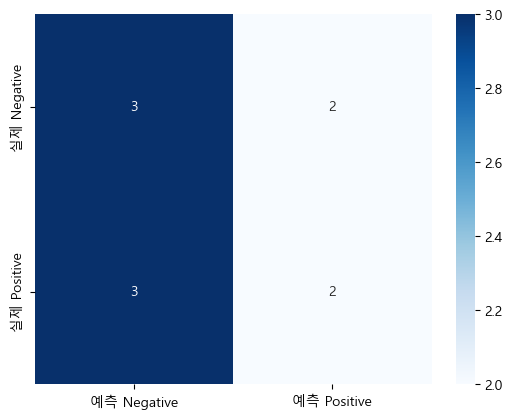

In [239]:
conf_matrix = confusion_matrix(y_true, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels= ['예측 Negative','예측 Positive'],
            yticklabels= ['실제 Negative','실제 Positive']
            )
plt.show()

In [240]:
y_true = np.array([0, 0, 0, 1, 1, 0, 0, 1, 1, 0])
x_prob = np.array([0.1, 0.4, 0.35, 0.8, 0.9, 0.2, 0.3, 0.6, 0.7, 0.2])
threshold = 0.8 # 확실한 경우만 1로 보겠음...
# 정밀도, 재현율
y_predict = (y_scores >= x_prob).astype(int)
print( precision_score(y_true,y_predict),
        recall_score(y_true,y_predict)
)

threshold = 0.3 # 대략적으로 비슷하면 1로 보겠음...
# 정밀도, 재현율
y_predict = (x_prob>=threshold).astype(int)
print( precision_score(y_true, y_predict),
        recall_score(y_true, y_predict)
)

0.4 1.0
0.5714285714285714 1.0


# [3교시]

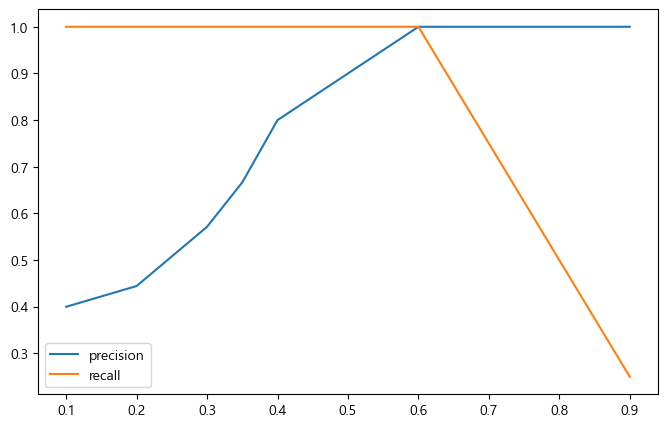

In [241]:
from sklearn.metrics import precision_recall_curve
precision, recall, threshold = precision_recall_curve(y_true, x_prob)
precision, recall, threshold

plt.figure(figsize=(8,5))
plt.plot(threshold, precision[:-1], label='precision')
plt.plot(threshold, recall[:-1], label='recall')
plt.legend()
plt.show()

- ROC ( ROC Curve )
    - 기준선을 바꿔가면서 진짜 정답을 맞추는 비율 TPR 
    $$\text{TPR}=\frac{TP}{TP+FN}$$
    - 오답을 정답이라고 판단한 비율 FPR 
    $$\text{FPR}=\frac{FP}{FP+TN}$$
- AUC ( Area Under the Curve )


[0.         0.16666667 0.16666667 0.33333333 0.33333333 0.66666667
 1.        ] 
 [0.   0.25 0.5  0.5  1.   1.   1.  ] 
 [ inf 0.9  0.8  0.75 0.6  0.3  0.2 ]
AUC(곡선 아래 면적) 0.7708


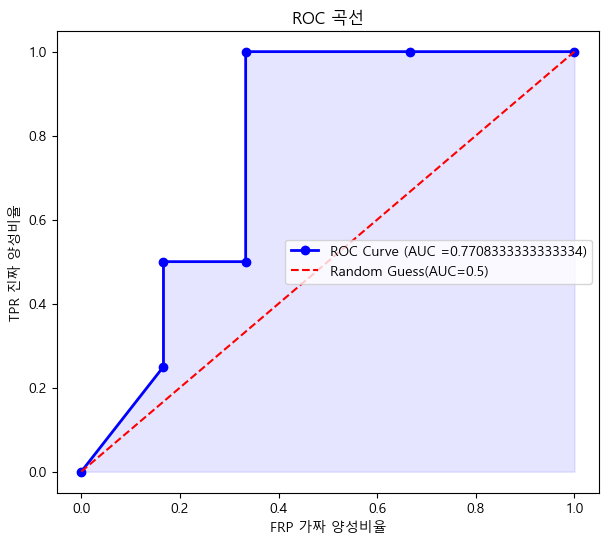

In [242]:
from sklearn.metrics import roc_curve, roc_auc_score

y_true = np.array([0, 0, 0, 1, 1, 0, 0, 1, 1, 0])
x_prob = np.array([0.9, 0.2, 0.75, 0.8, 0.9, 0.4, 0.3, 0.6, 0.7, 0.2])

roc_curve(y_true, x_prob)
fpr, tpr, threshold = roc_curve(y_true, x_prob)
print(fpr,'\n', tpr,'\n', threshold)
roc_auc = roc_auc_score(y_true, x_prob)
print(f"AUC(곡선 아래 면적) {roc_auc:.4f}")

# ROC 곡선
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='b', linewidth=2, marker='o', label=f'ROC Curve (AUC ={roc_auc})')
plt.plot([0,1], [0,1], color='red', linestyle='--', label = 'Random Guess(AUC=0.5)')
plt.fill_between(fpr, tpr, color='b', alpha=0.1)
plt.title('ROC 곡선')
plt.xlabel('FRP 가짜 양성비율')
plt.ylabel('TPR 진짜 양성비율')
plt.legend()
plt.show()

- 암 진단처럼 재현율이 우선인 모델을 만들자
    - 1. 결과값에 threshold를 낮게 부여해서 recall 값을 올리는 threshold를 찾는 방법
    - 2. 학습할 때 암환자를 놓치는 경우에 패널티를 강하게 부여(손실함수를 수정 BCEWitLogitLoss의 파라메터 조정)

In [243]:
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [244]:
from collections import Counter
data = load_breast_cancer()
X = data.data
y = 1 - data.target # 악성을 1, 양성(정상) 0

print( Counter(y) )

# 데이터 분리 클래스 비율 유지 8:2
x_train,x_test,y_train,y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)

# 스케일링
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# tensor로 변경
x_train_t = torch.FloatTensor(x_train)
y_train_t = torch.FloatTensor(y_train)
x_test_t = torch.FloatTensor(x_test)
y_test_t = torch.FloatTensor(y_test)

Counter({np.int64(0): 357, np.int64(1): 212})


In [245]:
x_train_t.shape

torch.Size([455, 30])

In [246]:
# 신경망 제작
# hidden (x_dim, 32)
# hidden (32, 16)
# hidden (16, 1)
# 활성함수 ReLU

class Network(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)
    
def print_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    ps = precision_score(y_true, y_pred)
    rs = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"confusion_matrix : \n{cm}")
    print(f"precision_score : {ps:.4f}")
    print(f"***recall_score*** : {rs:.4f}")
    print(f"f1_score : {f1:.4f}")

model = Network(x_train_t.shape[-1])

In [247]:
import torch.optim as optim
torch.manual_seed(42)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
epochs = 100
for epoch in range(epochs):
    optimizer.zero_grad()
    y_predict = model(x_train_t).squeeze(1)
    loss = criterion(y_predict, y_train_t)
    loss.backward()
    optimizer.step()

with torch.no_grad():
    logits = model(x_test_t)
    probs = torch.sigmoid(logits).numpy()

threshold = 0.00003
preds_05 = (probs >= threshold).astype(int)
print_metrics(y_test, preds_05)


confusion_matrix : 
[[61 11]
 [ 1 41]]
precision_score : 0.7885
***recall_score*** : 0.9762
f1_score : 0.8723


In [249]:
# nn.BCEWithLogitsLoss pos_weight 값이 높으면 1을 0으로 놓쳤을 때 더 강한 패널티를 부여 (높은 손실점수)
torch.manual_seed(42)
# 암환자(1) 놓치는 것에 대해 정상(0) 보다 10배의 가중치(패널티) 부여
weight_for_positive = torch.tensor([10.0])
model_weighted = Network(x_train_t.shape[-1])
creiterion_weighted = nn.BCEWithLogitsLoss(pos_weight=weight_for_positive)
optim_weighted = Adam(model_weighted.parameters(), lr=0.01)

epochs = 100
for epoch in range(epochs):
    optim_weighted.zero_grad()
    y_predict = model_weighted(x_train_t).squeeze(1)
    loss = creiterion_weighted(y_predict, y_train_t)
    loss.backward()
    optim_weighted.step()

with torch.no_grad():
    logits = model_weighted(x_test_t)
    probs = torch.sigmoid(logits).numpy()

threshold = 0.00003
preds_05 = (probs >= threshold).astype(int)
print_metrics(y_test, preds_05)


confusion_matrix : 
[[42 30]
 [ 0 42]]
precision_score : 0.5833
***recall_score*** : 1.0000
f1_score : 0.7368


AUC(곡선아래 면적) 0.7708


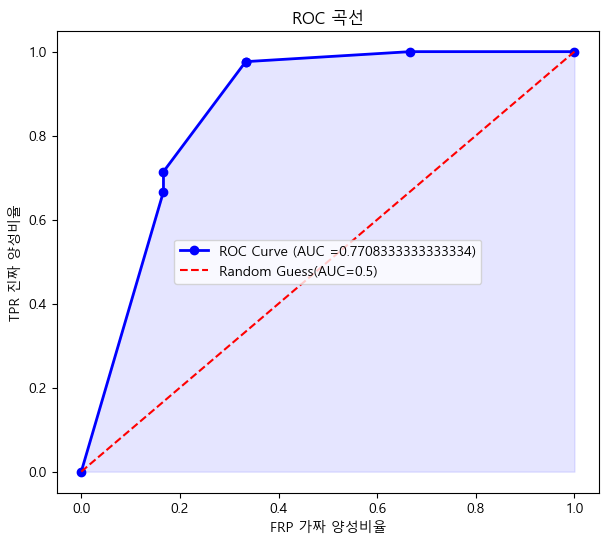

In [251]:
fqr, tpr, threshold = roc_curve(y_test, probs)

roc_auc = roc_auc_score(y_true, x_prob)
print(f'AUC(곡선아래 면적) {roc_auc:.4f}')

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='b', linewidth=2, marker='o', label=f'ROC Curve (AUC ={roc_auc})')
plt.plot([0,1], [0,1], color='red', linestyle='--', label = 'Random Guess(AUC=0.5)')
plt.fill_between(fpr, tpr, color='b', alpha=0.1)
plt.title('ROC 곡선')
plt.xlabel('FRP 가짜 양성비율')
plt.ylabel('TPR 진짜 양성비율')
plt.legend()
plt.show()

- 정상(N) 사기(P)
- Credit Card Fraud Detection
    - 99.89% 정상거래, 0.17% 사기거래
- 중요한 평가 지표 : Recall
    - 사기거래를 정상거래로 잘못 분류( FN ) - 고객 피해 및 장기적 고객 이탈(비즈니스의 문제)
    - 정상거래를 사기거래로 잘못 분류( FP ) - 고객 항의, 달래기 가능
- 사기거래를 놓치면 안되는 경우 - 재현율(Recall) 중요


In [261]:
from sklearn.datasets import fetch_openml
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
import pandas as pd

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [254]:
data = fetch_openml(name='creditcard', as_frame=True, parser='auto').frame

In [265]:
y = pd.to_numeric(data.iloc[:,-1].values)
X = data.drop(columns=['Class'], axis=1).to_numpy()

X.shape, y.shape

((284807, 29), (284807,))

In [268]:
x_train,x_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

x_train_t = torch.FloatTensor(x_train)
y_train_t = torch.FloatTensor(y_train)
x_test_t = torch.FloatTensor(x_test)
y_test_t = torch.FloatTensor(y_test)

In [274]:
class DetectFraud(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)
    
#불균형 비율 만큼 positive(1) 클래스에 가중치 부여 - 사기
num_pos = sum(y_train == 1)
num_neg = sum(y_train == 0)
pos_weight_val = torch.Tensor([num_neg / num_pos]) # 정상 데이터 수 / 사기 데이터 수

model = DetectFraud(x_train_t.shape[-1])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val)
optimizer = Adam(model.parameters(), lr=0.01)

In [286]:
from sklearn.metrics import classification_report
def evaluate_model(model, x, y):
    with torch.no_grad():
        logits = model(x)
        probs = torch.sigmoid(logits)
        preds = (probs >=0.5).int()
        print(f"confusion matrix : {confusion_matrix(y, preds)}")
        print(classification_report(y, preds, target_names = ['0 정상', '1 사기']))
        return probs

In [278]:
from torch.utils.data import TensorDataset, DataLoader
epochs = 20
batch_size = 2048
dataset = TensorDataset(x_train_t, y_train_t)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

from tqdm import tqdm
for epoch in tqdm(range(epochs)):
    total_loss = 0
    for batch_x, batch_y in dataloader:
        optimizer.zero_grad()
        output = model(batch_x).squeeze(1)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(dataloader)
    if (epoch+1) % 5 == 0:
        print(f'epoch : {epoch+1}/{epochs} 평균 loss = {avg_loss:.4f}')
    

 25%|██▌       | 5/20 [00:08<00:25,  1.68s/it]

epoch : 5/20 평균 loss = 0.1729


 50%|█████     | 10/20 [00:17<00:17,  1.77s/it]

epoch : 10/20 평균 loss = 0.1186


 75%|███████▌  | 15/20 [00:27<00:10,  2.01s/it]

epoch : 15/20 평균 loss = 0.0730


100%|██████████| 20/20 [00:37<00:00,  1.89s/it]

epoch : 20/20 평균 loss = 0.0493


In [287]:
test_probs = evaluate_model(model, x_test_t, y_test_t)

confusion matrix : [[56228   636]
 [   10    88]]
              precision    recall  f1-score   support

        0 정상       1.00      0.99      0.99     56864
        1 사기       0.12      0.90      0.21        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.60     56962
weighted avg       1.00      0.99      0.99     56962

